<a href="https://colab.research.google.com/github/supekavya/FullStackDataScience/blob/Machine-Learning/Polynomial_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd



path = '/Position_Salaries.csv'
# Importing the dataset
dataset = pd.read_csv(path)

# Independent variable (Position Level)
X = dataset.iloc[:, 1:-1].values

# Dependent variable (Salary)
y = dataset.iloc[:, -1].values

# Display dataset preview
print("Dataset Preview:")
print(dataset.head())




Dataset Preview:
            Position  Level  Salary
0   Business Analyst      1   45000
1  Junior Consultant      2   50000
2  Senior Consultant      3   60000
3            Manager      4   80000
4    Country Manager      5  110000


In [ ]:
# Training the Linear Regression model on the whole dataset
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X, y)

# Training the Polynomial Regression model on the whole dataset
from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree = 4)
X_poly = poly_reg.fit_transform(X)
lin_reg_2 = LinearRegression()
lin_reg_2.fit(X_poly, y)

print("✅ Models Trained Successfully!")




✅ Models Trained Successfully!


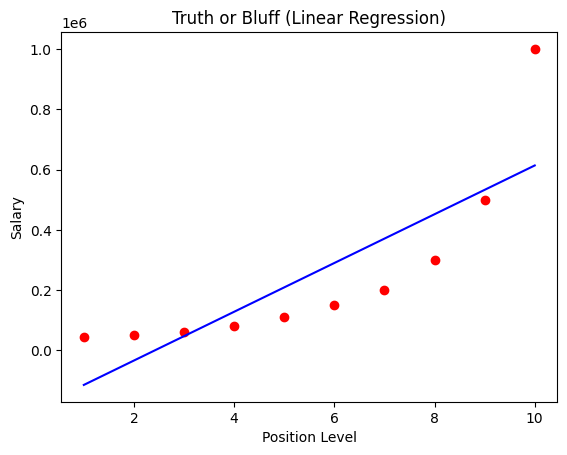

In [ ]:
# Visualising the Linear Regression results
plt.scatter(X, y, color = 'red')
plt.plot(X, lin_reg.predict(X), color = 'blue')
plt.title('Truth or Bluff (Linear Regression)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.show()




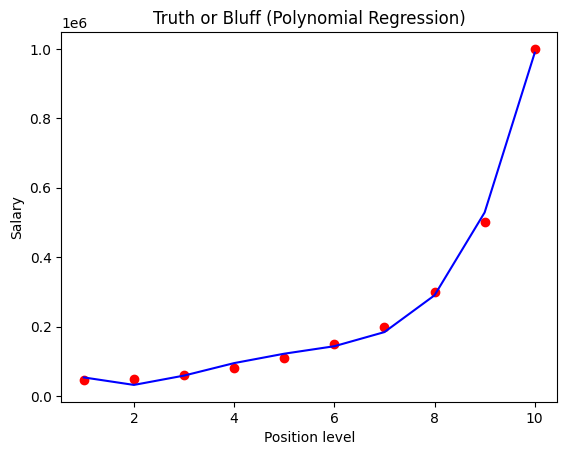

/tmp/ipython-input-177888312.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.1)


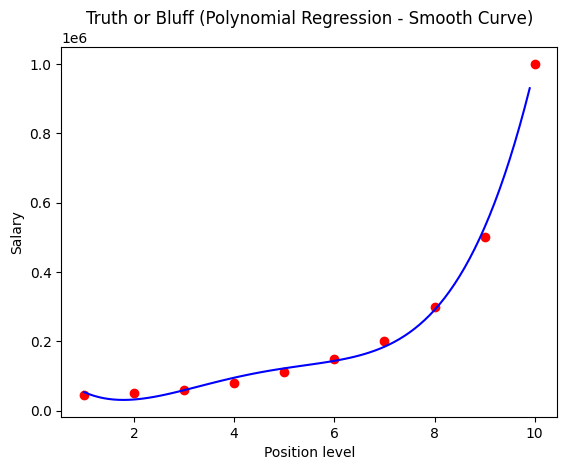

In [ ]:
# Visualising the Polynomial Regression results
plt.scatter(X, y, color = 'red')
plt.plot(X, lin_reg_2.predict(poly_reg.fit_transform(X)), color = 'blue')
plt.title('Truth or Bluff (Polynomial Regression)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()


# Visualising the Polynomial Regression results (for higher resolution and smoother curve)
X_grid = np.arange(min(X), max(X), 0.1)
X_grid = X_grid.reshape((len(X_grid), 1))
plt.scatter(X, y, color = 'red')
plt.plot(X_grid, lin_reg_2.predict(poly_reg.fit_transform(X_grid)), color = 'blue')
plt.title('Truth or Bluff (Polynomial Regression - Smooth Curve)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()




In [ ]:
# Predicting a new result with Linear Regression
linear_prediction = lin_reg.predict([[6.5]])
print("Linear Regression Prediction for Level 6.5:", linear_prediction)


# Predicting a new result with Polynomial Regression
poly_prediction = lin_reg_2.predict(poly_reg.fit_transform([[6.5]]))
print("Polynomial Regression Prediction for Level 6.5:", poly_prediction)



Linear Regression Prediction for Level 6.5: [330378.78787879]
Polynomial Regression Prediction for Level 6.5: [158862.45265155]


🧠 Business Scenario
An automobile company wants to understand how engine size affects the price of a car.
From past observations, the product team believes:
For small engines, price increases slowly
For medium engines, price increases rapidly
For very large engines, price growth slows down due to luxury saturation
This indicates that the relationship between engine size and price is not strictly linear.
You are hired as a Data Analyst to analyze this pattern and build a model that can predict car prices accurately.

📝 Tasks
1. Load the dataset and identify the relevant columns.

2. Use:

-Engine size as the input feature

-Car price as the output variable

3. Visualize the relationship between engine size and price.

4. Build a predictive model to estimate car price based on engine size.

5. Predict the price for a car with:
Engine size = 200

6. Increase the flexibility of your model and observe how the curve changes.

7. Compare predictions from:
a simple straight-line model
a curved model

8. Analyze which model:
captures the trend better
gives more realistic predictions

9. Evaluate prediction errors and interpret them in business terms.

10. Answer the following:

Why does a straight-line model fail here?

What risk occurs if the curve becomes too flexible?

Which model would you recommend for production and why?

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
df = pd.read_csv("/CarPrice_Assignment.csv")

df[['enginesize', 'price']].head()

,enginesize,price
0,130,13495.0
1,130,16500.0
2,152,16500.0
3,109,13950.0
4,136,17450.0


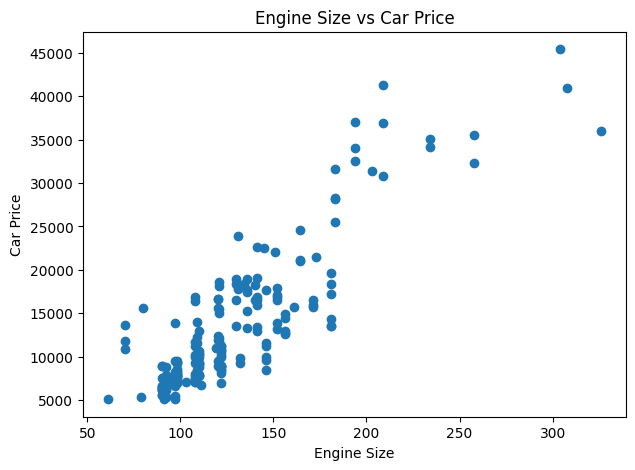

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(df['enginesize'], df['price'])
plt.xlabel("Engine Size")
plt.ylabel("Car Price")
plt.title("Engine Size vs Car Price")
plt.show()


In [ ]:
from sklearn.linear_model import LinearRegression

X = df[['enginesize']]
y = df['price']

linear_model = LinearRegression()
linear_model.fit(X, y)

y_pred_linear = linear_model.predict(X)


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)

X_sorted = np.sort(X.values, axis=0)
X_sorted_poly = poly.transform(X_sorted)
y_pred_poly = poly_model.predict(X_sorted_poly)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


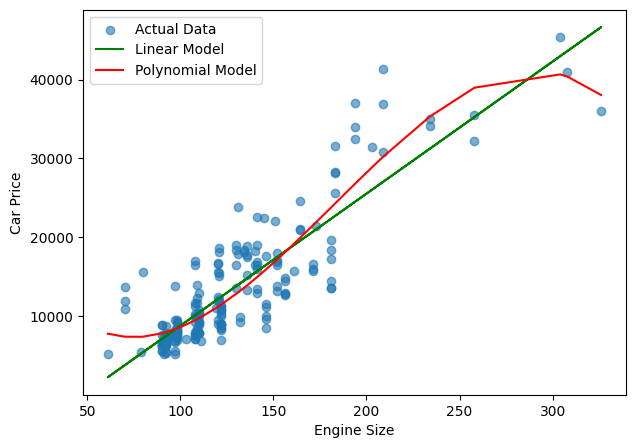

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(X, y, label="Actual Data", alpha=0.6)
plt.plot(X, y_pred_linear, color="green", label="Linear Model")
plt.plot(X_sorted, y_pred_poly, color="red", label="Polynomial Model")
plt.xlabel("Engine Size")
plt.ylabel("Car Price")
plt.legend()
plt.show()


In [ ]:
engine_200 = poly.transform([[200]])
predicted_price = poly_model.predict(engine_200)
predicted_price[0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


np.float64(28207.451636708214)

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# Linear model
mse_linear = mean_squared_error(y, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)

# Polynomial model
mse_poly = mean_squared_error(y, poly_model.predict(X_poly))
rmse_poly = np.sqrt(mse_poly)

# R² scores
r2_linear = r2_score(y, y_pred_linear)
r2_poly = r2_score(y, poly_model.predict(X_poly))

rmse_linear, rmse_poly, r2_linear, r2_poly

(np.float64(3870.4342657576967),
 np.float64(3618.221247975695),
 0.7641291357806176,
 0.7938681287369995)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model = LinearRegression()
model.fit(X_train_poly, y_train)
train_score = model.score(X_train_poly, y_train)


test_score = model.score(X_test_poly, y_test)

train_score, test_score


(0.7513000480657894, 0.8019117595258543)

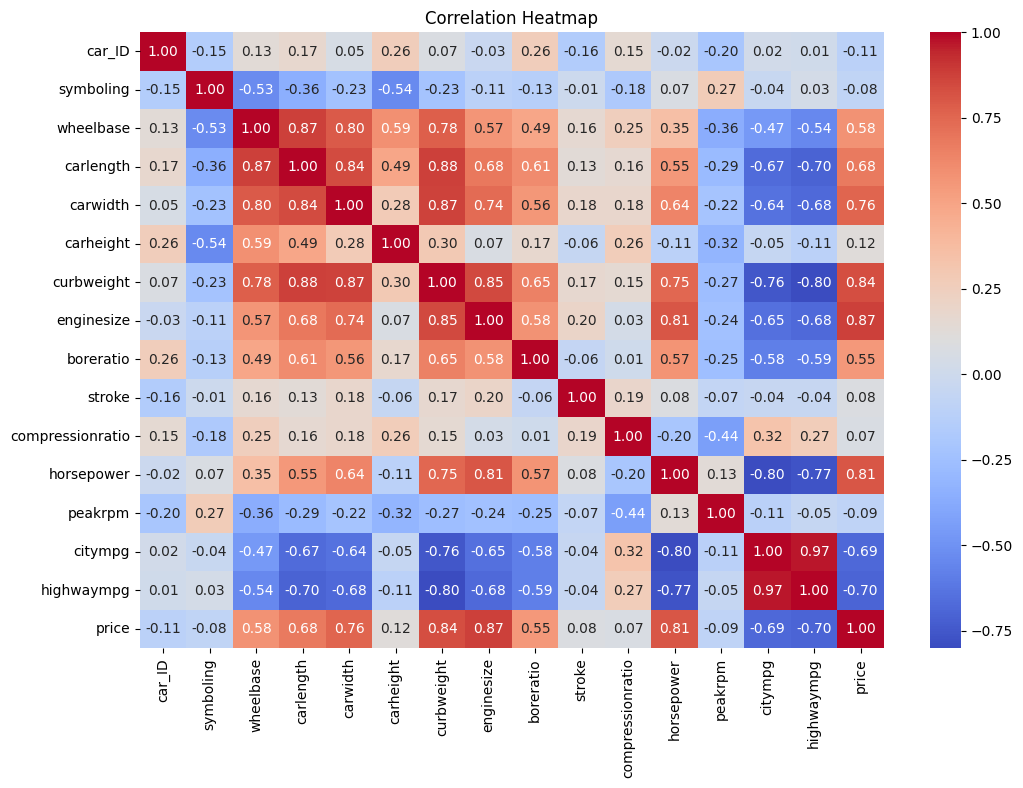

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
df_numeric = df.select_dtypes(include=[np.number])

# Correlation matrix
corr = df_numeric.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


These variables increase price significantly as they increase:

Engine Size (0.87)

Strongest positive correlation

Larger engines → higher performance → higher price

Curb Weight (0.84)

Heavier cars usually mean stronger build and premium features

Horsepower (0.81)

High horsepower directly increases perceived value

Car Width (0.76)

Wider cars are often premium or luxury models

Car Length (0.68)

Longer cars generally belong to higher segments

Wheelbase (0.58)

enginesize  strong positive +0.87

curbweight  strong positive +0.84

horsepower  strong positive +0.81

carwidth    strong positive +0.76

carlength  moderate postitive +0.68

wheelbase  moderate positive +0.58

boreratio moderate postitive +0.55

highwaympg strong negative -0.70

citympg strong negative -0.69

carheight weak postive +0.12

compressionration weak postive +0.07

stroke weak positive +0.08

symboling weak negative -0.08

peakrpm weak negative -0.09

car_ID weak negative -0.11


In [ ]:
import pandas as pd
import numpy as np

corr = df.select_dtypes(include=[np.number]).corr()

target_corr = corr['price'].drop('price')

def classify_correlation(value):
    if value >= 0.7:
        return "Strong Positive"
    elif 0.4 <= value < 0.7:
        return "Moderate Positive"
    elif 0.1 <= value < 0.4:
        return "Weak Positive"
    elif -0.1 < value < 0.1:
        return "No / Very Weak"
    elif -0.4 < value <= -0.1:
        return "Weak Negative"
    elif -0.7 < value <= -0.4:
        return "Moderate Negative"
    else:
        return "Strong Negative"

correlation_analysis = pd.DataFrame({
    'Feature': target_corr.index,
    'Correlation_Value': target_corr.values,
    'Relationship': target_corr.values
})

correlation_analysis['Relationship'] = correlation_analysis['Correlation_Value'].apply(classify_correlation)

correlation_analysis.sort_values(by='Correlation_Value', ascending=False)


,Feature,Correlation_Value,Relationship
7,enginesize,0.874145,Strong Positive
6,curbweight,0.835305,Strong Positive
11,horsepower,0.808139,Strong Positive
4,carwidth,0.759325,Strong Positive
3,carlength,0.682920,Moderate Positive
2,wheelbase,0.577816,Moderate Positive
8,boreratio,0.553173,Moderate Positive
5,carheight,0.119336,Weak Positive
9,stroke,0.079443,No / Very Weak
10,compressionratio,0.067984,No / Very Weak


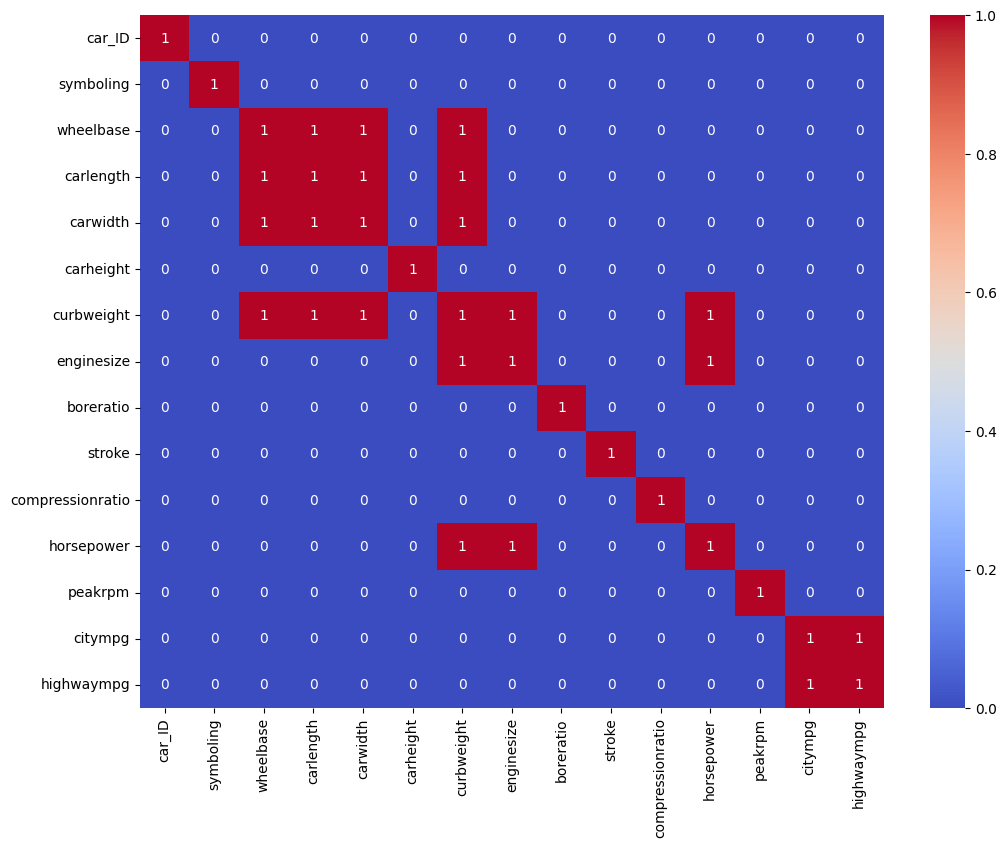

In [ ]:
x=df.drop('price',axis=1)

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,9))
sns.heatmap(x.corr(numeric_only=True)>0.75, annot=True,cmap='coolwarm')
plt.show()

In [ ]:
import numpy as np

def get_highly_correlated_pairs(df, threshold=0.75):
    """
    Prints highly correlated feature pairs above a given threshold.

    Parameters:
    df : pandas DataFrame (numeric columns only)
    threshold : float (default = 0.75)
    """

    # Compute correlation matrix
    corr_matrix = df.select_dtypes(include=[np.number]).corr()

    # Loop through upper triangle only
    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):
            corr_value = corr_matrix.iloc[i, j]

            if abs(corr_value) >= threshold:
                print(f"{corr_matrix.columns[i]} and {corr_matrix.columns[j]}: {corr_value}")
get_highly_correlated_pairs(df, threshold=0.75)


wheelbase and carlength: 0.874587475964264
wheelbase and carwidth: 0.795143643616968
wheelbase and curbweight: 0.7763863277822105
carlength and carwidth: 0.8411182684818453
carlength and curbweight: 0.8777284608306433
carwidth and curbweight: 0.8670324646791233
carwidth and price: 0.759325299741511
curbweight and enginesize: 0.850594073426277
curbweight and horsepower: 0.7507392514434825
curbweight and citympg: -0.757413784505601
curbweight and highwaympg: -0.7974647922811803
curbweight and price: 0.8353048793372975
enginesize and horsepower: 0.8097686545377302
enginesize and price: 0.8741448025245117
horsepower and citympg: -0.8014561756662708
horsepower and highwaympg: -0.7705438913729603
horsepower and price: 0.8081388225362214
citympg and highwaympg: 0.9713370423425045


In [ ]:
drop_cols = [
    'carlength', 'carwidth', 'curbweight',
    'horsepower', 'highwaympg','carheight','compressionratio','stroke',
    'symboling','peakrpm'
]

df_final = df.drop(columns=drop_cols)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Feature & target
X = df[['enginesize']]
y = df['price']

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Polynomial transformation (FIX degree here)
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# 4. Train model
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# 5. Scores
train_score = poly_model.score(X_train_poly, y_train)
test_score = poly_model.score(X_test_poly, y_test)

# 6. Prediction (NOW THIS WILL WORK)
y_test_pred = poly_model.predict(X_test_poly)

train_score, test_score


(0.7513000480657894, 0.8019117595258543)

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2 = r2_score(y_test, y_test_pred)

rmse, r2


(np.float64(3954.47622220764), 0.8019117595258543)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

Ridge()

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred_ridge = ridge.predict(X_test_scaled)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

rmse_ridge, r2_ridge


(np.float64(3936.9548310097553), 0.8036632392332959)

In [ ]:
ridge_coeff = pd.Series(ridge.coef_, index=X.columns)
ridge_coeff.sort_values(ascending=False)


,0
enginesize,6650.520672


In [ ]:
from sklearn.linear_model import RidgeCV
import numpy as np
model=RidgeCV(alphas=alphas)
alphas=np.arange(0.1,10,0.05)
model.fit(X_train, y_train)
print("Best alpha:", model.alpha_)
print("best score: ",model.score(X_test,y_test))

Best alpha: 9.950000000000003
best score:  0.8040933847321597


In [ ]:
from sklearn.linear_model import LassoCV
import numpy as np
alphas=np.arange(0.1,10,0.05)
model=LassoCV(alphas=alphas)
model.fit(X_train, y_train)
print("Best alpha:", model.alpha_)
print("best score: ",model.score(X_test,y_test))

Best alpha: 9.950000000000003
best score:  0.8040934124003777
